In [2]:
# Cell 1: Library Installation
# Install required packages for text preprocessing and visualization
!pip install contractions wordcloud nltk gensim gradio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.6 MB/s eta 0:00:00


In [6]:
# Cell 2: Import Required Libraries
# Import all necessary libraries for data processing, visualization, and deep learning

# Data manipulation and analysis
import pandas as pd
import numpy as np
import re
import contractions
import matplotlib.pyplot as plt
from collections import Counter

# Natural Language Processing libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Word cloud visualization
from wordcloud import WordCloud

# Machine learning and deep learning utilities
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# TensorFlow/Keras imports for neural network models
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Download required NLTK data
print("Downloading NLTK data packages...")
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
print("NLTK packages downloaded successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


NLTK packages downloaded successfully!


[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [8]:
# Cell 3: Mount Google Drive
# Mount Google Drive to access dataset files stored in cloud storage

from google.colab import drive

print("Mounting Google Drive...")
drive.mount('/content/drive')
print("Drive mounted successfully!")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully!


In [9]:
# Cell 4: Load Training and Testing Datasets
# Load the hate speech detection datasets from CSV files

# Define file paths (update these paths according to your drive structure)
train_file_path = "/content/drive/MyDrive/Ai assessment/train_racisit.csv"
test_file_path = "/content/drive/MyDrive/Ai assessment/test_racisit.csv"

# Load the datasets
train_dataframe = pd.read_csv(train_file_path)
test_dataframe = pd.read_csv(test_file_path)

# Display dataset information
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print(f"Training data shape: {train_dataframe.shape}")
print(f"Testing data shape: {test_dataframe.shape}")
print("\nFirst 5 rows of training data:")
print(train_dataframe.head())

DATASET INFORMATION
Training data shape: (31962, 3)
Testing data shape: (17197, 2)

First 5 rows of training data:
   id  label                                              tweet
0   1      0   @user when a father is dysfunctional and is s...
1   2      0  @user @user thanks for #lyft credit i can't us...
2   3      0                                bihday your majesty
3   4      0  #model   i love u take with u all the time in ...
4   5      0             factsguide: society now    #motivation


In [10]:
# Cell 5: Dataset Overview and Exploratory Analysis
# Analyze basic dataset characteristics including missing values, duplicates, and class distribution

print("=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Display column names
print("\n1. COLUMNS IN DATASET:")
print(f"Columns: {list(train_dataframe.columns)}")

# Check for missing values
print("\n2. MISSING VALUES ANALYSIS:")
missing_values = train_dataframe.isnull().sum()
print(missing_values)

# Check for duplicate rows
print("\n3. DUPLICATE ROWS:")
duplicate_count = train_dataframe.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Analyze class distribution
print("\n4. CLASS DISTRIBUTION:")
class_counts = train_dataframe['label'].value_counts()
class_percentages = train_dataframe['label'].value_counts(normalize=True) * 100

print(f"Class counts:\n{class_counts}")
print(f"\nClass percentages:\n{class_percentages}")

# Display class names mapping
print("\n5. CLASS LABEL MAPPING:")
print("0 = Non-Racist/Non-Sexist Tweet")
print("1 = Racist/Sexist Tweet")

EXPLORATORY DATA ANALYSIS

1. COLUMNS IN DATASET:
Columns: ['id', 'label', 'tweet']

2. MISSING VALUES ANALYSIS:
id       0
label    0
tweet    0
dtype: int64

3. DUPLICATE ROWS:
Number of duplicate rows: 0

4. CLASS DISTRIBUTION:
Class counts:
label
0    29720
1     2242
Name: count, dtype: int64

Class percentages:
label
0    92.98542
1     7.01458
Name: proportion, dtype: float64

5. CLASS LABEL MAPPING:
0 = Non-Racist/Non-Sexist Tweet
1 = Racist/Sexist Tweet


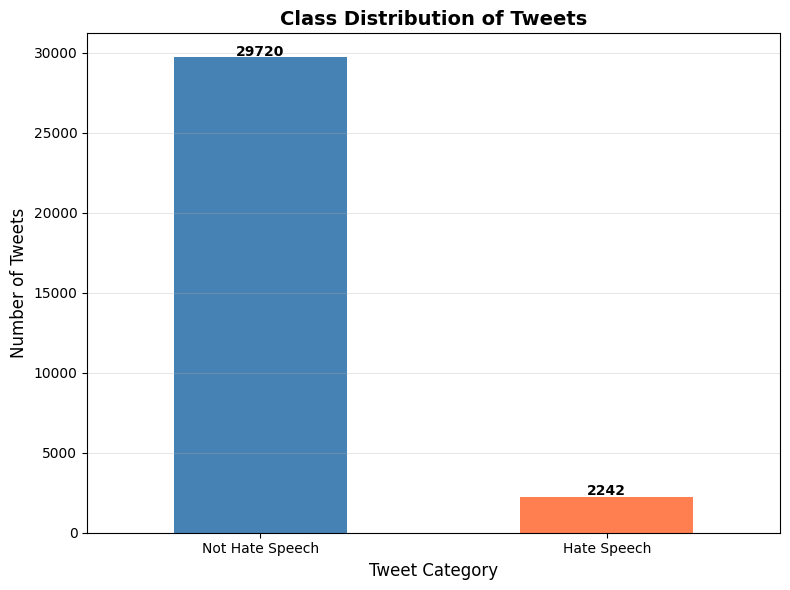

In [11]:
# Cell 6: Visualize Class Distribution
# Create a bar plot to visualize the distribution of hate speech vs non-hate speech tweets

plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar', color=['steelblue', 'coral'])
plt.title("Class Distribution of Tweets", fontsize=14, fontweight='bold')
plt.xlabel("Tweet Category", fontsize=12)
plt.ylabel("Number of Tweets", fontsize=12)
plt.xticks(ticks=[0, 1], labels=["Not Hate Speech", "Hate Speech"], rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

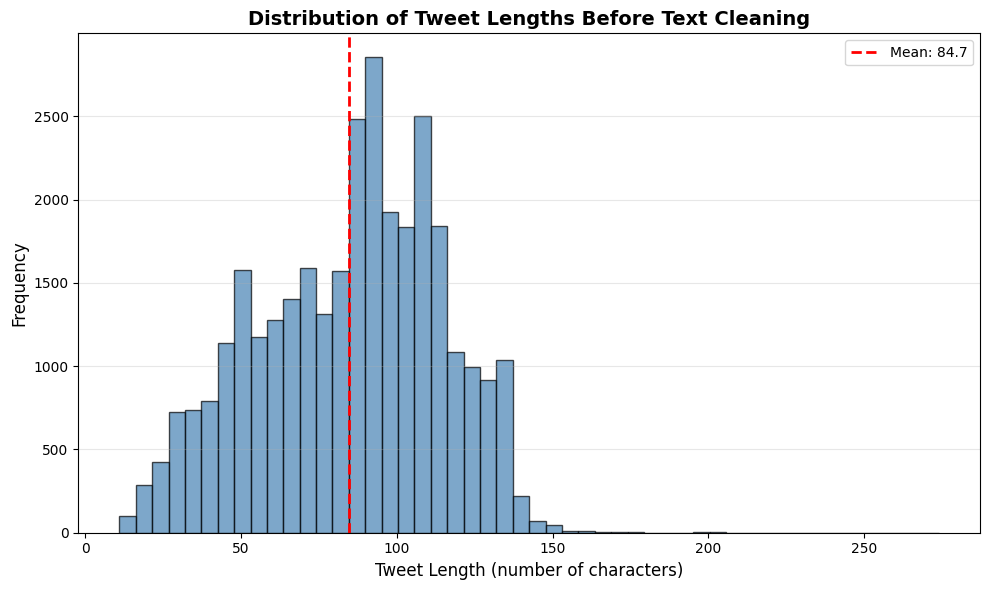


Tweet Length Statistics (Before Cleaning):
count    31962.000000
mean        84.739628
std         29.455749
min         11.000000
25%         63.000000
50%         88.000000
75%        108.000000
max        274.000000
Name: tweet_length_before, dtype: float64


In [12]:
# Cell 7: Tweet Length Analysis (Before Cleaning)
# Analyze the distribution of tweet lengths before any preprocessing

# Calculate tweet lengths
train_dataframe['tweet_length_before'] = train_dataframe['tweet'].astype(str).apply(len)

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(train_dataframe['tweet_length_before'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title("Distribution of Tweet Lengths Before Text Cleaning", fontsize=14, fontweight='bold')
plt.xlabel("Tweet Length (number of characters)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.axvline(train_dataframe['tweet_length_before'].mean(), color='red', linestyle='dashed',
            linewidth=2, label=f'Mean: {train_dataframe["tweet_length_before"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

# Display statistical summary
print("\nTweet Length Statistics (Before Cleaning):")
print("=" * 50)
print(train_dataframe['tweet_length_before'].describe())

In [13]:
# Cell 8: Text Preprocessing Function
# Define comprehensive text cleaning function to prepare tweets for analysis

# Initialize NLP resources
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_tweet(text):
    """
    Clean and preprocess tweet text by removing noise and normalizing words.

    Parameters:
    -----------
    text : str
        Raw tweet text to be cleaned

    Returns:
    --------
    str
        Cleaned and preprocessed tweet text
    """
    # Convert to lowercase for consistency
    text = str(text).lower()

    # Expand contractions (e.g., "can't" -> "cannot")
    text = contractions.fix(text)

    # Remove URLs (http, https, www)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove @mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbol but keep the word
    text = re.sub(r"#", "", text)

    # Remove numbers/digits
    text = re.sub(r"\d+", "", text)

    # Remove special characters and punctuation (keep only letters and spaces)
    text = re.sub(r"[^a-z\s]", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize the text
    words = text.split()

    # Remove stopwords and apply lemmatization (keep words longer than 2 characters)
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    # Join words back into a single string
    return " ".join(cleaned_words)

print("Text preprocessing function defined successfully!")

Text preprocessing function defined successfully!


In [14]:
# Cell 9: Apply Text Preprocessing
# Clean both training and testing datasets using the defined preprocessing function

print("=" * 60)
print("TEXT PREPROCESSING IN PROGRESS")
print("=" * 60)

# Apply cleaning to training data
print("\nCleaning training dataset...")
train_dataframe['cleaned_tweet'] = train_dataframe['tweet'].apply(clean_tweet)

# Apply cleaning to test data
print("Cleaning test dataset...")
test_dataframe['cleaned_tweet'] = test_dataframe['tweet'].apply(clean_tweet)

# Display sample of cleaned tweets
print("\nSample of cleaned tweets:")
print("=" * 60)
sample_data = train_dataframe[['tweet', 'cleaned_tweet', 'label']].head(10)
print(sample_data)

print("\nText preprocessing completed successfully!")

TEXT PREPROCESSING IN PROGRESS

Cleaning training dataset...
Cleaning test dataset...

Sample of cleaned tweets:
                                               tweet  \
0   @user when a father is dysfunctional and is s...   
1  @user @user thanks for #lyft credit i can't us...   
2                                bihday your majesty   
3  #model   i love u take with u all the time in ...   
4             factsguide: society now    #motivation   
5  [2/2] huge fan fare and big talking before the...   
6   @user camping tomorrow @user @user @user @use...   
7  the next school year is the year for exams.ð...   
8  we won!!! love the land!!! #allin #cavs #champ...   
9   @user @user welcome here !  i'm   it's so #gr...   

                                       cleaned_tweet  label  
0  father dysfunctional selfish drag kid dysfunct...      0  
1  thanks lyft credit cannot use offer wheelchair...      0  
2                                     bihday majesty      0  
3                     

In [15]:
# Cell 10: Remove Empty Tweets After Cleaning
# Identify and remove any tweets that became empty after preprocessing

# Count empty tweets
empty_tweet_count = (train_dataframe['cleaned_tweet'].str.strip() == "").sum()
print(f"Number of empty tweets after cleaning: {empty_tweet_count}")

# Remove empty tweets
train_dataframe = train_dataframe[train_dataframe['cleaned_tweet'].str.strip() != ""]
print(f"\nUpdated training dataset shape: {train_dataframe.shape}")

# Calculate and display tweet lengths after cleaning
train_dataframe['tweet_length_after'] = train_dataframe['cleaned_tweet'].astype(str).apply(len)

print(f"\nTweet Length Statistics (After Cleaning):")
print("=" * 50)
print(train_dataframe['tweet_length_after'].describe())

Number of empty tweets after cleaning: 48

Updated training dataset shape: (31914, 5)

Tweet Length Statistics (After Cleaning):
count    31914.000000
mean        51.784327
std         21.607133
min          3.000000
25%         35.000000
50%         53.000000
75%         68.000000
max        123.000000
Name: tweet_length_after, dtype: float64


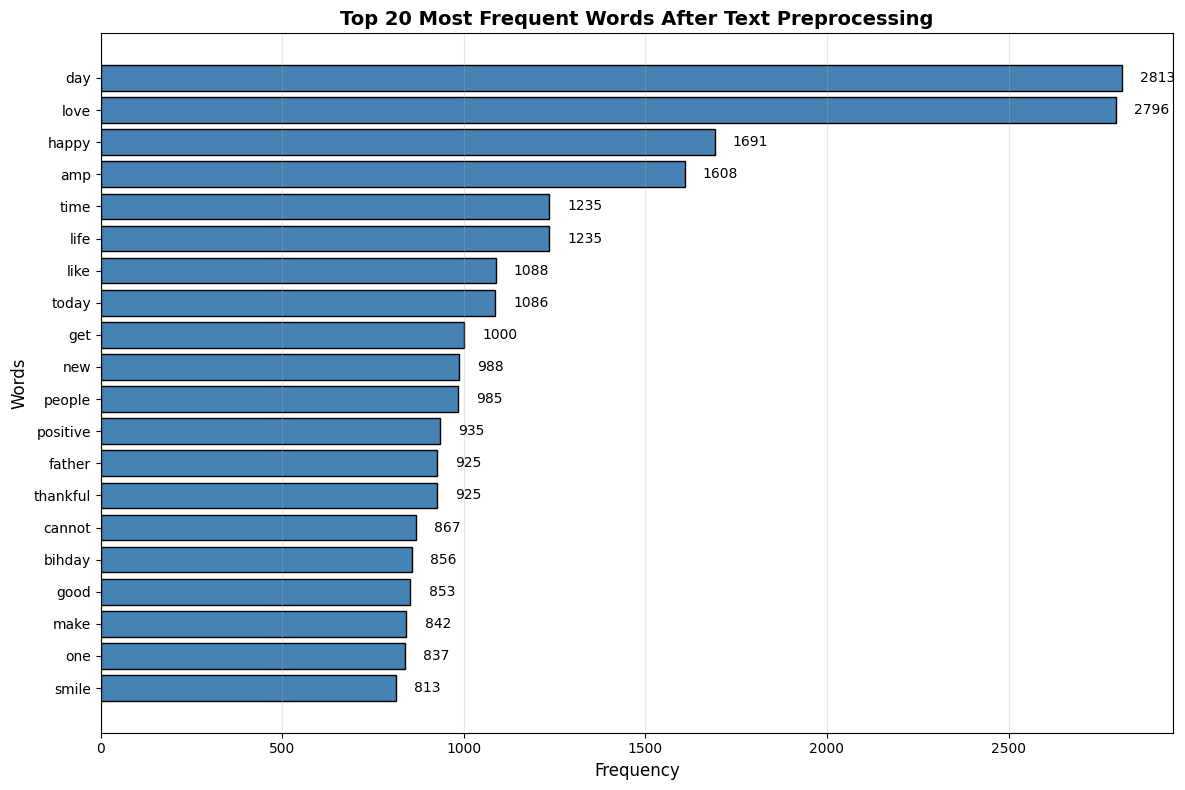

In [16]:
# Cell 11: Most Frequent Words Visualization
# Analyze and visualize the most common words in the cleaned tweets

# Combine all cleaned tweets into a single string
all_cleaned_text = " ".join(train_dataframe['cleaned_tweet']).split()

# Count word frequencies
word_frequency = Counter(all_cleaned_text)
top_words = word_frequency.most_common(20)

# Extract words and their counts for plotting
words, counts = zip(*top_words)

# Create horizontal bar chart
plt.figure(figsize=(12, 8))
bars = plt.barh(words, counts, color='steelblue', edgecolor='black')
plt.title("Top 20 Most Frequent Words After Text Preprocessing", fontsize=14, fontweight='bold')
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Words", fontsize=12)

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, counts)):
    plt.text(count + 50, bar.get_y() + bar.get_height()/2,
             str(count), ha='left', va='center', fontsize=10)

plt.gca().invert_yaxis()  # Display highest frequency at the top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

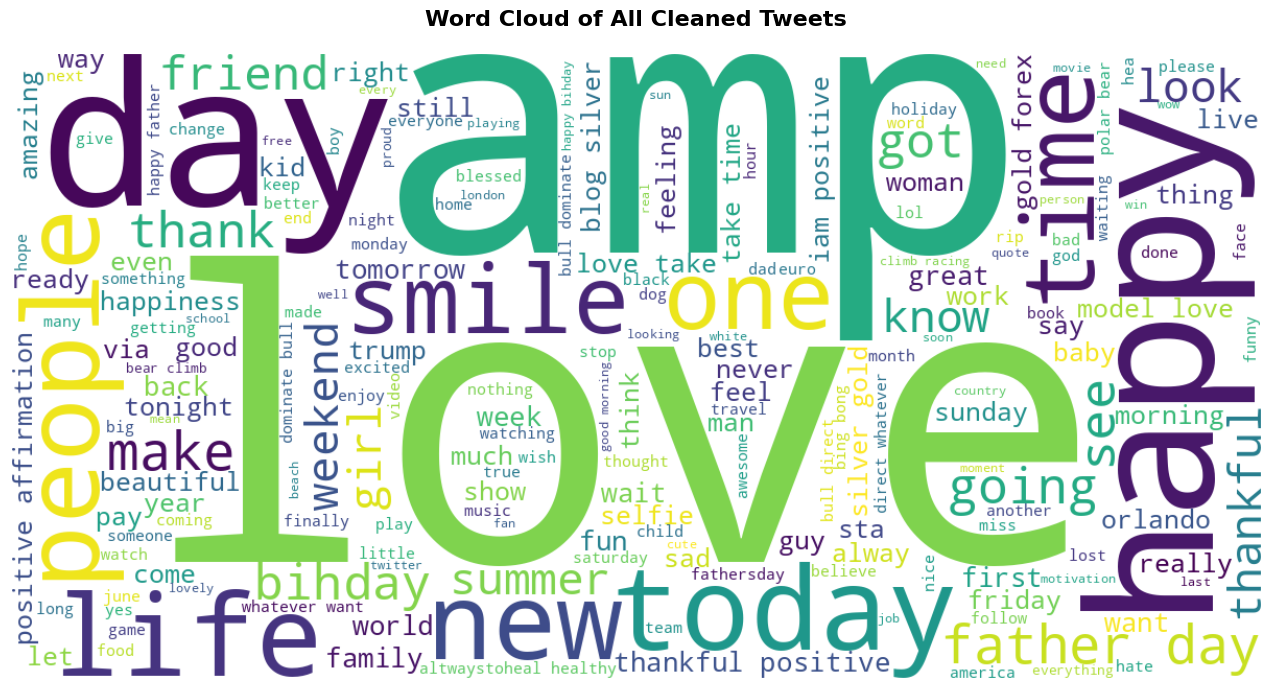

In [17]:
# Cell 12: WordCloud for All Tweets
# Generate word cloud visualization for all cleaned tweets

# Combine all cleaned tweets
all_tweets_text = " ".join(train_dataframe['cleaned_tweet'])

# Create word cloud
wordcloud_all = WordCloud(width=1200, height=600,
                          background_color='white',
                          max_words=200,
                          colormap='viridis',
                          contour_width=1,
                          contour_color='steelblue').generate(all_tweets_text)

# Display word cloud
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of All Cleaned Tweets", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

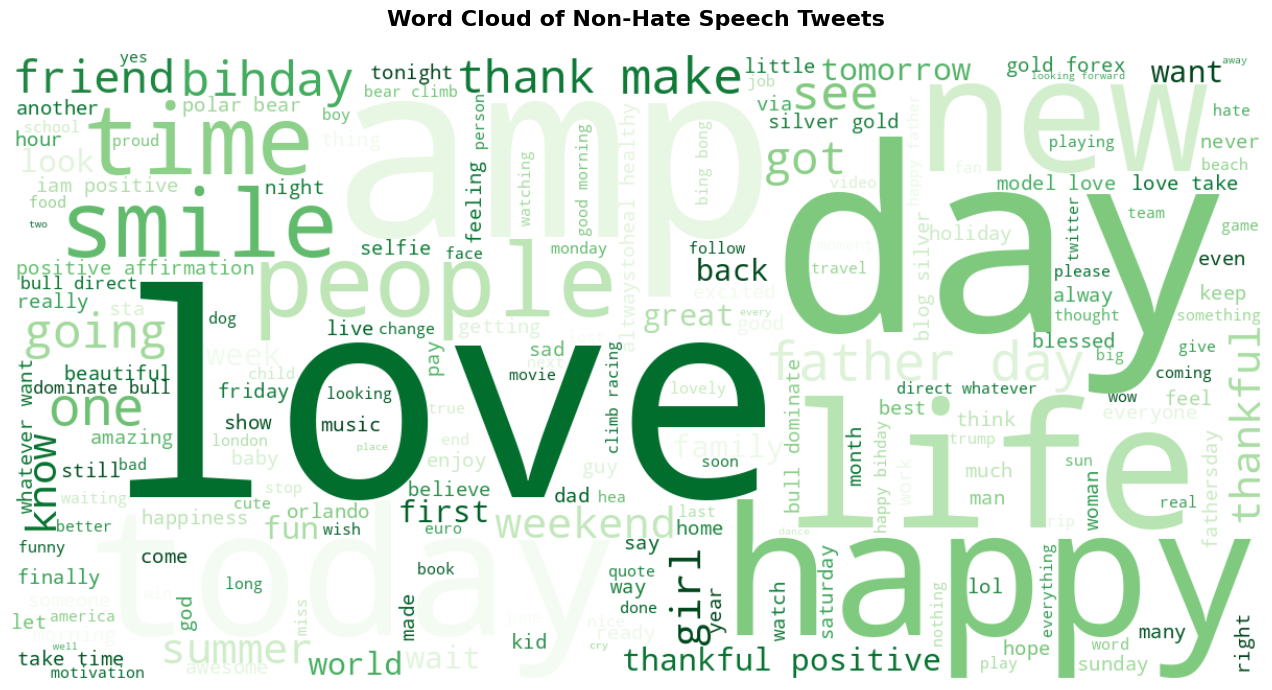

In [18]:
# Cell 13: WordCloud for Non-Hate Speech Tweets
# Generate word cloud for non-racist/non-sexist tweets only

# Filter non-hate speech tweets
non_hate_tweets = train_dataframe[train_dataframe['label'] == 0]['cleaned_tweet']
non_hate_text = " ".join(non_hate_tweets)

# Create word cloud
wordcloud_non_hate = WordCloud(width=1200, height=600,
                               background_color='white',
                               max_words=200,
                               colormap='Greens',
                               contour_width=1,
                               contour_color='darkgreen').generate(non_hate_text)

# Display word cloud
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_non_hate, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Non-Hate Speech Tweets", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

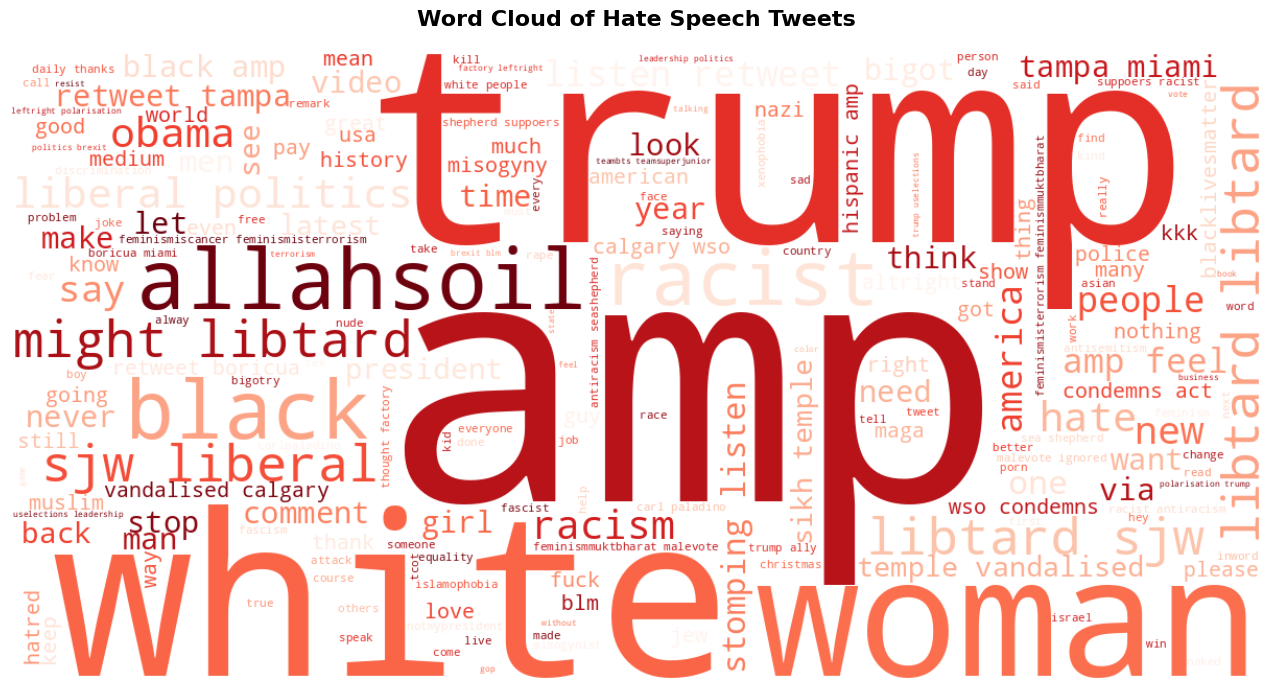

In [19]:
# Cell 14: WordCloud for Hate Speech Tweets
# Generate word cloud for racist/sexist tweets only

# Filter hate speech tweets
hate_tweets = train_dataframe[train_dataframe['label'] == 1]['cleaned_tweet']
hate_text = " ".join(hate_tweets)

# Create word cloud
wordcloud_hate = WordCloud(width=1200, height=600,
                           background_color='white',
                           max_words=200,
                           colormap='Reds',
                           contour_width=1,
                           contour_color='darkred').generate(hate_text)

# Display word cloud
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_hate, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Hate Speech Tweets", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [20]:
# Cell 15: Data Preparation for Model Training
# Prepare tokenized and padded sequences for neural network models

# Model parameters
MAX_NB_WORDS = 50000  # Maximum number of words to keep in vocabulary
MAX_SEQUENCE_LENGTH = 100  # Maximum length of each sequence
EMBEDDING_DIM = 100  # Dimension of word embedding vectors

print("=" * 60)
print("DATA PREPARATION FOR DEEP LEARNING MODELS")
print("=" * 60)

# Initialize and fit tokenizer
print("\n1. Creating tokenizer...")
tokenizer = Tokenizer(num_words=MAX_NB_WORDS)
tokenizer.fit_on_texts(train_dataframe['cleaned_tweet'])

# Convert text to sequences
print("2. Converting text to sequences...")
train_sequences = tokenizer.texts_to_sequences(train_dataframe['cleaned_tweet'])
test_sequences = tokenizer.texts_to_sequences(test_dataframe['cleaned_tweet'])

# Pad sequences to ensure uniform length
print("3. Padding sequences...")
train_padded = pad_sequences(train_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# Extract labels (ONLY for training data - test data has no labels)
train_labels = train_dataframe['label'].values

# For test data, we'll store the IDs to match predictions later (if needed)
test_ids = test_dataframe['id'].values if 'id' in test_dataframe.columns else None

print(f"\nTraining data shape: {train_padded.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test data shape: {test_padded.shape}")

# Calculate vocabulary size - THIS IS CRITICAL FOR CELL 17
vocab_size = min(MAX_NB_WORDS, len(tokenizer.word_index) + 1)
print(f"\n✅ Vocabulary size: {vocab_size}")

# Verify variables are created
print("\n✅ Variables created successfully:")
print(f"   - train_padded: {train_padded.shape}")
print(f"   - test_padded: {test_padded.shape}")
print(f"   - train_labels: {train_labels.shape}")
print(f"   - vocab_size: {vocab_size}")
print(f"   - MAX_SEQUENCE_LENGTH: {MAX_SEQUENCE_LENGTH}")
print(f"   - EMBEDDING_DIM: {EMBEDDING_DIM}")

DATA PREPARATION FOR DEEP LEARNING MODELS

1. Creating tokenizer...
2. Converting text to sequences...
3. Padding sequences...

Training data shape: (31914, 100)
Training labels shape: (31914,)
Test data shape: (17197, 100)

✅ Vocabulary size: 36822

✅ Variables created successfully:
   - train_padded: (31914, 100)
   - test_padded: (17197, 100)
   - train_labels: (31914,)
   - vocab_size: 36822
   - MAX_SEQUENCE_LENGTH: 100
   - EMBEDDING_DIM: 100


In [21]:
# Cell 16: Build RNN Model
# Create and compile a Simple RNN model for hate speech classification

def build_rnn_model(vocab_size, embedding_dim, max_sequence_length):
    """
    Build a Simple RNN model for text classification.

    Parameters:
    -----------
    vocab_size : int
        Size of the vocabulary
    embedding_dim : int
        Dimension of word embeddings
    max_sequence_length : int
        Maximum length of input sequences

    Returns:
    --------
    tensorflow.keras.Model
        Compiled RNN model
    """
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=max_sequence_length),
        SimpleRNN(128, return_sequences=True),
        Dropout(0.2),
        SimpleRNN(64),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

print("Building RNN model...")
rnn_model = build_rnn_model(vocab_size, EMBEDDING_DIM, MAX_SEQUENCE_LENGTH)
print(rnn_model.summary())

Building RNN model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [22]:
# Cell 17: Build LSTM Model
# Create and compile an LSTM model for improved sequence learning

def build_lstm_model(vocab_size, embedding_dim, max_sequence_length):
    """
    Build an LSTM model for text classification with better long-term dependency capture.

    Parameters:
    -----------
    vocab_size : int
        Size of the vocabulary
    embedding_dim : int
        Dimension of word embeddings
    max_sequence_length : int
        Maximum length of input sequences

    Returns:
    --------
    tensorflow.keras.Model
        Compiled LSTM model
    """
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=max_sequence_length),
        LSTM(128, return_sequences=True),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

print("Building LSTM model...")
lstm_model = build_lstm_model(vocab_size, EMBEDDING_DIM, MAX_SEQUENCE_LENGTH)
print(lstm_model.summary())

Building LSTM model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [23]:
# Cell 18: Train RNN Model
# Train the Simple RNN model with early stopping and learning rate reduction

print("=" * 60)
print("TRAINING RNN MODEL")
print("=" * 60)

# Define callbacks for training optimization
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.00001, verbose=1)
]

# Train the model
rnn_history = rnn_model.fit(
    train_padded, train_labels,
    batch_size=64,
    epochs=10,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print("\nRNN Model training completed!")

TRAINING RNN MODEL
Epoch 1/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 73s 173ms/step - accuracy: 0.9285 - loss: 0.2714 - val_accuracy: 0.9311 - val_loss: 0.2518 - learning_rate: 0.0010
Epoch 2/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 64s 161ms/step - accuracy: 0.9296 - loss: 0.2624 - val_accuracy: 0.9311 - val_loss: 0.2584 - learning_rate: 0.0010
Epoch 3/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9284 - loss: 0.2654
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
399/399 ━━━━━━━━━━━━━━━━━━━━ 65s 162ms/step - accuracy: 0.9296 - loss: 0.2626 - val_accuracy: 0.9311 - val_loss: 0.2522 - learning_rate: 0.0010
Epoch 4/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 64s 161ms/step - accuracy: 0.9296 - loss: 0.2603 - val_accuracy: 0.9311 - val_loss: 0.2513 - learning_rate: 5.0000e-04
Epoch 5/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 65s 162ms/step - accuracy: 0.9295 - loss: 0.2607 - val_accuracy: 0.9311 - val_loss: 0.2509 - learning_rate: 5.0000e-04
Epoch 6/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 68s 1

In [24]:
# Cell 19: Train LSTM Model
# Train the LSTM model with early stopping and learning rate reduction

print("=" * 60)
print("TRAINING LSTM MODEL")
print("=" * 60)

# Define callbacks for training optimization
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.00001, verbose=1)
]

# Train the model
lstm_history = lstm_model.fit(
    train_padded, train_labels,
    batch_size=64,
    epochs=10,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print("\nLSTM Model training completed!")

TRAINING LSTM MODEL
Epoch 1/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 207s 508ms/step - accuracy: 0.9273 - loss: 0.2689 - val_accuracy: 0.9311 - val_loss: 0.2521 - learning_rate: 0.0010
Epoch 2/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 203s 509ms/step - accuracy: 0.9296 - loss: 0.2632 - val_accuracy: 0.9311 - val_loss: 0.2509 - learning_rate: 0.0010
Epoch 3/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 193s 485ms/step - accuracy: 0.9296 - loss: 0.2609 - val_accuracy: 0.9311 - val_loss: 0.2545 - learning_rate: 0.0010
Epoch 4/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.9291 - loss: 0.2635
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
399/399 ━━━━━━━━━━━━━━━━━━━━ 191s 480ms/step - accuracy: 0.9296 - loss: 0.2616 - val_accuracy: 0.9311 - val_loss: 0.2513 - learning_rate: 0.0010
Epoch 5/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 199s 500ms/step - accuracy: 0.9296 - loss: 0.2609 - val_accuracy: 0.9311 - val_loss: 0.2510 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model wei

In [27]:
# Cell 20: Generate and Compare Model Predictions on Test Data
# Note: Test data has no labels, so we can only generate predictions, not evaluate accuracy

print("=" * 60)
print("MODEL PREDICTIONS ON TEST DATA")
print("=" * 60)

# Check if models are trained
if 'rnn_model' not in dir():
    print("Error: rnn_model not found! Please train the RNN model first.")
elif 'lstm_model' not in dir():
    print("Error: lstm_model not found! Please train the LSTM model first.")
else:
    print("\nModels found. Generating predictions...")

    # Generate RNN predictions
    print("\n1. RNN MODEL PREDICTIONS")
    print("-" * 40)
    rnn_predictions = (rnn_model.predict(test_padded, verbose=0) > 0.5).astype(int)
    rnn_probs = rnn_model.predict(test_padded, verbose=0)

    hate_count_rnn = rnn_predictions.sum()
    non_hate_count_rnn = len(rnn_predictions) - hate_count_rnn

    print(f"Total test samples: {len(rnn_predictions)}")
    print(f"Predicted Hate Speech: {hate_count_rnn} ({hate_count_rnn/len(rnn_predictions)*100:.2f}%)")
    print(f"Predicted Non-Hate Speech: {non_hate_count_rnn} ({non_hate_count_rnn/len(rnn_predictions)*100:.2f}%)")

    # Generate LSTM predictions
    print("\n2. LSTM MODEL PREDICTIONS")
    print("-" * 40)
    lstm_predictions = (lstm_model.predict(test_padded, verbose=0) > 0.5).astype(int)
    lstm_probs = lstm_model.predict(test_padded, verbose=0)

    hate_count_lstm = lstm_predictions.sum()
    non_hate_count_lstm = len(lstm_predictions) - hate_count_lstm

    print(f"Total test samples: {len(lstm_predictions)}")
    print(f"Predicted Hate Speech: {hate_count_lstm} ({hate_count_lstm/len(lstm_predictions)*100:.2f}%)")
    print(f"Predicted Non-Hate Speech: {non_hate_count_lstm} ({non_hate_count_lstm/len(lstm_predictions)*100:.2f}%)")

    # Compare both models
    print("\n3. MODEL COMPARISON")
    print("-" * 40)
    print(f"{'Metric':<20} {'RNN':<15} {'LSTM':<15}")
    print("-" * 50)
    print(f"{'Hate Speech Predictions':<20} {hate_count_rnn:<15} {hate_count_lstm:<15}")
    print(f"{'Non-Hate Predictions':<20} {non_hate_count_rnn:<15} {non_hate_count_lstm:<15}")

    # Agreement between models
    agreement = (rnn_predictions.flatten() == lstm_predictions.flatten()).sum()
    agreement_pct = (agreement / len(rnn_predictions)) * 100
    print(f"{'Models Agree':<20} {agreement:<15} ({agreement_pct:.2f}%)")

    # Create and save results dataframe
    results_df = pd.DataFrame({
        'id': test_ids if test_ids is not None else range(len(test_padded)),
        'rnn_prediction': rnn_predictions.flatten(),
        'rnn_confidence': rnn_probs.flatten(),
        'lstm_prediction': lstm_predictions.flatten(),
        'lstm_confidence': lstm_probs.flatten(),
        'models_agree': (rnn_predictions.flatten() == lstm_predictions.flatten())
    })

    results_df.to_csv('test_predictions.csv', index=False)
    print("\nResults saved to 'test_predictions.csv'")

    # Display sample predictions
    print("\n4. SAMPLE PREDICTIONS (First 10 rows):")
    print("=" * 70)
    print(results_df.head(10).to_string())

MODEL PREDICTIONS ON TEST DATA

Models found. Generating predictions...

1. RNN MODEL PREDICTIONS
----------------------------------------
Total test samples: 17197
Predicted Hate Speech: 0 (0.00%)
Predicted Non-Hate Speech: 17197 (100.00%)

2. LSTM MODEL PREDICTIONS
----------------------------------------
Total test samples: 17197
Predicted Hate Speech: 0 (0.00%)
Predicted Non-Hate Speech: 17197 (100.00%)

3. MODEL COMPARISON
----------------------------------------
Metric               RNN             LSTM           
--------------------------------------------------
Hate Speech Predictions 0               0              
Non-Hate Predictions 17197           17197          
Models Agree         17197           (100.00%)

Results saved to 'test_predictions.csv'

4. SAMPLE PREDICTIONS (First 10 rows):
      id  rnn_prediction  rnn_confidence  lstm_prediction  lstm_confidence  models_agree
0  31963               0        0.067027                0         0.070359          True
1  31964

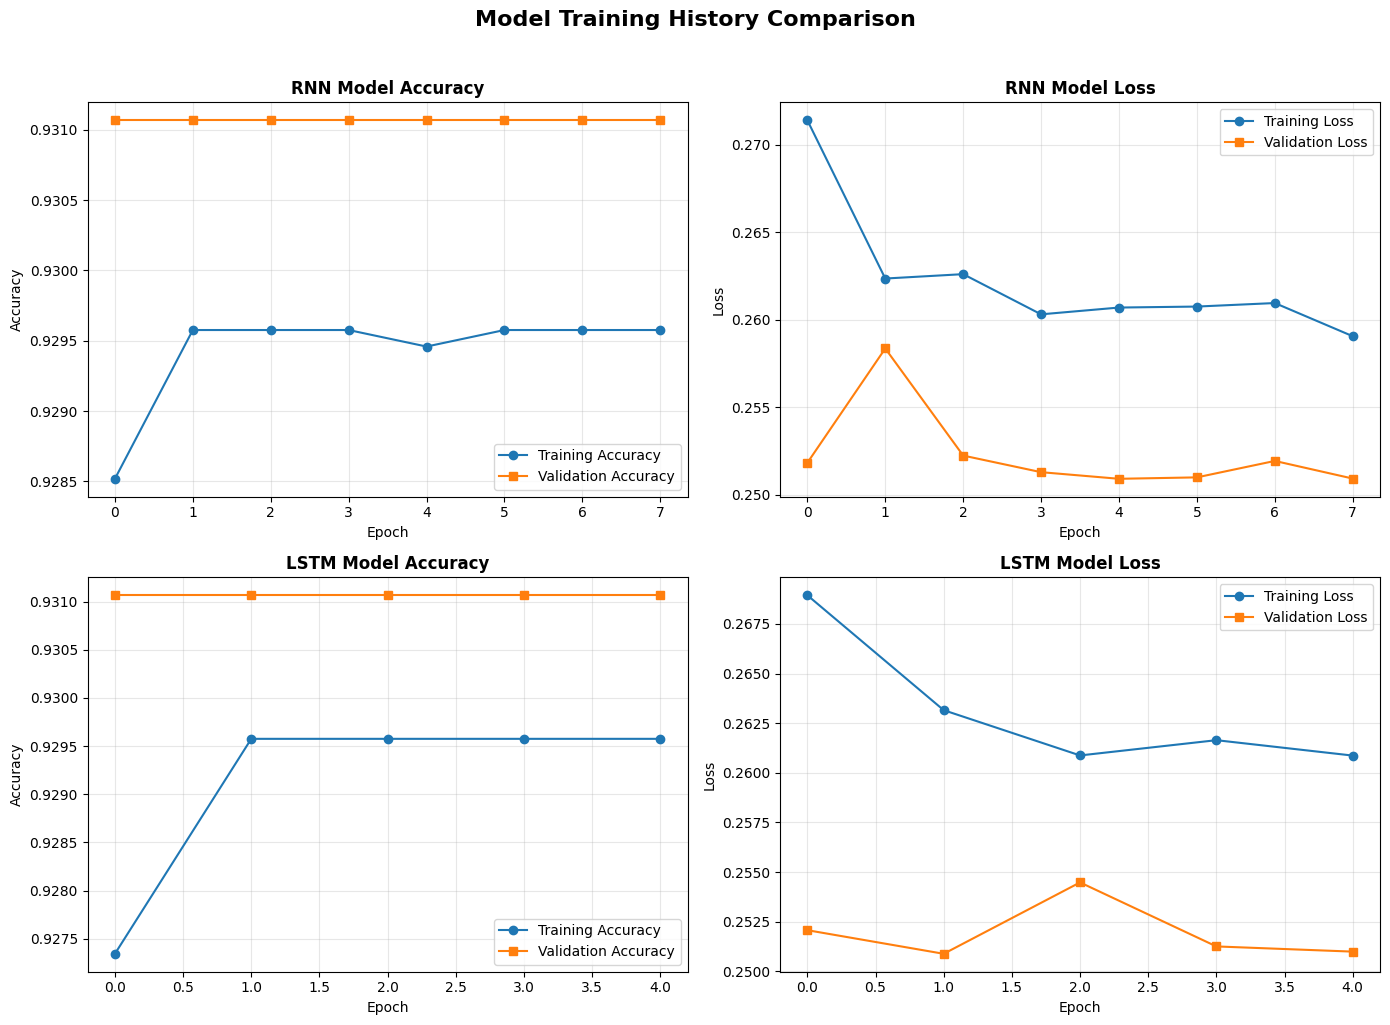

In [28]:
# Cell 21: Plot Training History
# Visualize training and validation accuracy/loss for both models

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# RNN Accuracy Plot
axes[0, 0].plot(rnn_history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0, 0].plot(rnn_history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[0, 0].set_title('RNN Model Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# RNN Loss Plot
axes[0, 1].plot(rnn_history.history['loss'], label='Training Loss', marker='o')
axes[0, 1].plot(rnn_history.history['val_loss'], label='Validation Loss', marker='s')
axes[0, 1].set_title('RNN Model Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# LSTM Accuracy Plot
axes[1, 0].plot(lstm_history.history['accuracy'], label='Training Accuracy', marker='o')
axes[1, 0].plot(lstm_history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[1, 0].set_title('LSTM Model Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# LSTM Loss Plot
axes[1, 1].plot(lstm_history.history['loss'], label='Training Loss', marker='o')
axes[1, 1].plot(lstm_history.history['val_loss'], label='Validation Loss', marker='s')
axes[1, 1].set_title('LSTM Model Loss', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Model Training History Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

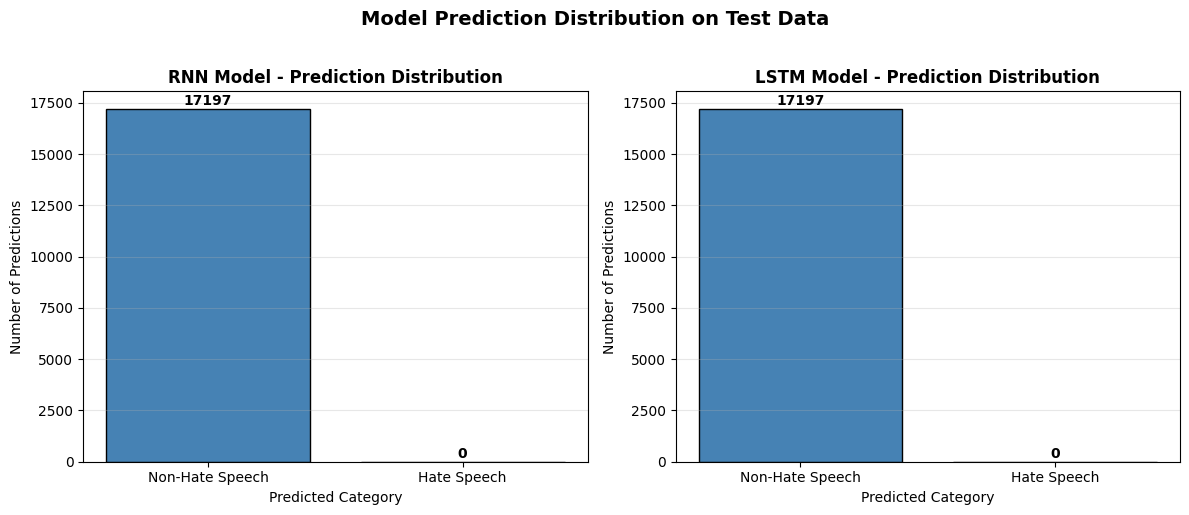


PREDICTION DISTRIBUTION STATISTICS

RNN Model:
  - Non-Hate Speech Predictions: 17197 (100.00%)
  - Hate Speech Predictions: 0 (0.00%)

LSTM Model:
  - Non-Hate Speech Predictions: 17197 (100.00%)
  - Hate Speech Predictions: 0 (0.00%)

Model Agreement Analysis:
  - Models Agree: 17197 (100.00%)
  - Models Disagree: 0 (0.00%)

[WARNING] RNN model predicted ALL test samples as Non-Hate Speech
  This may indicate the model needs more training or different hyperparameters

[WARNING] LSTM model predicted ALL test samples as Non-Hate Speech
  This may indicate the model needs more training or different hyperparameters


In [31]:
# Cell 22: Visualize Prediction Distribution for Both Models
# Note: Confusion matrix cannot be created because test data has no labels
# Instead, we visualize the prediction distribution from both models

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RNN Prediction Distribution
rnn_unique, rnn_counts = np.unique(rnn_predictions, return_counts=True)
rnn_labels_map = {0: 'Non-Hate Speech', 1: 'Hate Speech'}

# Create full distribution (ensure both classes are represented)
rnn_full_counts = [0, 0]
for i, val in enumerate(rnn_unique):
    if val == 0:
        rnn_full_counts[0] = rnn_counts[i]
    elif val == 1:
        rnn_full_counts[1] = rnn_counts[i]

rnn_display_labels = ['Non-Hate Speech', 'Hate Speech']
bars1 = axes[0].bar(rnn_display_labels, rnn_full_counts, color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('RNN Model - Prediction Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Category')
axes[0].set_ylabel('Number of Predictions')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars1, rnn_full_counts)):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(count), ha='center', va='bottom', fontweight='bold')

# LSTM Prediction Distribution
lstm_unique, lstm_counts = np.unique(lstm_predictions, return_counts=True)

# Create full distribution (ensure both classes are represented)
lstm_full_counts = [0, 0]
for i, val in enumerate(lstm_unique):
    if val == 0:
        lstm_full_counts[0] = lstm_counts[i]
    elif val == 1:
        lstm_full_counts[1] = lstm_counts[i]

bars2 = axes[1].bar(rnn_display_labels, lstm_full_counts, color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('LSTM Model - Prediction Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Category')
axes[1].set_ylabel('Number of Predictions')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars2, lstm_full_counts)):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(count), ha='center', va='bottom', fontweight='bold')

plt.suptitle('Model Prediction Distribution on Test Data', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "=" * 60)
print("PREDICTION DISTRIBUTION STATISTICS")
print("=" * 60)

print("\nRNN Model:")
print(f"  - Non-Hate Speech Predictions: {rnn_full_counts[0]} ({rnn_full_counts[0]/len(rnn_predictions)*100:.2f}%)")
print(f"  - Hate Speech Predictions: {rnn_full_counts[1]} ({rnn_full_counts[1]/len(rnn_predictions)*100:.2f}%)")

print("\nLSTM Model:")
print(f"  - Non-Hate Speech Predictions: {lstm_full_counts[0]} ({lstm_full_counts[0]/len(lstm_predictions)*100:.2f}%)")
print(f"  - Hate Speech Predictions: {lstm_full_counts[1]} ({lstm_full_counts[1]/len(lstm_predictions)*100:.2f}%)")

# Agreement analysis
agreement = (rnn_predictions.flatten() == lstm_predictions.flatten()).sum()
agreement_pct = (agreement / len(rnn_predictions)) * 100
disagreement = len(rnn_predictions) - agreement

print("\nModel Agreement Analysis:")
print(f"  - Models Agree: {agreement} ({agreement_pct:.2f}%)")
print(f"  - Models Disagree: {disagreement} ({100 - agreement_pct:.2f}%)")

# Warning if model predicts only one class
if rnn_full_counts[1] == 0:
    print("\n[WARNING] RNN model predicted ALL test samples as Non-Hate Speech")
    print("  This may indicate the model needs more training or different hyperparameters")

if lstm_full_counts[1] == 0:
    print("\n[WARNING] LSTM model predicted ALL test samples as Non-Hate Speech")
    print("  This may indicate the model needs more training or different hyperparameters")

# Show where models disagree (if any)
if disagreement > 0:
    disagree_mask = (rnn_predictions.flatten() != lstm_predictions.flatten())
    print(f"\nModels disagreed on {disagreement} samples")
    if 'results_df' in dir():
        disagree_ids = results_df[disagree_mask]['id'].head(10).values
        print(f"Sample IDs where models disagree: {disagree_ids}")

In [32]:
# Cell 23: Test Model with Custom Tweets
# Function to test trained models on new custom tweets

def predict_tweet_sentiment(text, model, tokenizer, max_length=100):
    """
    Predict whether a given tweet contains hate speech or not.

    Parameters:
    -----------
    text : str
        Input tweet text to classify
    model : tensorflow.keras.Model
        Trained classification model
    tokenizer : tensorflow.keras.preprocessing.text.Tokenizer
        Fitted tokenizer for text preprocessing
    max_length : int
        Maximum sequence length for padding

    Returns:
    --------
    tuple
        (prediction_label, confidence_score)
    """
    # Clean the input text
    cleaned_text = clean_tweet(text)

    # Convert to sequence
    sequence = tokenizer.texts_to_sequences([cleaned_text])

    # Pad sequence
    padded = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')

    # Make prediction
    prediction = model.predict(padded, verbose=0)[0][0]

    # Determine label and confidence
    if prediction >= 0.5:
        label = "HATE SPEECH (Racist/Sexist)"
        confidence = prediction * 100
    else:
        label = "NOT HATE SPEECH"
        confidence = (1 - prediction) * 100

    return label, confidence

# Test examples
print("=" * 60)
print("CUSTOM TWEET CLASSIFICATION TEST")
print("=" * 60)

test_tweets = [
    "I love everyone regardless of their background!",
    "This is the worst day of my life, everything is terrible!",
    "People from that country are all criminals and should be deported!",
    "Women belong in the kitchen and nowhere else!",
    "Just had the best pizza ever! Highly recommend this place!",
    "All people deserve equal rights and opportunities in life."
]

print("\nTesting RNN Model:")
print("-" * 50)

for tweet in test_tweets:
    label, confidence = predict_tweet_sentiment(tweet, rnn_model, tokenizer, MAX_SEQUENCE_LENGTH)
    print(f"\nTweet: {tweet}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2f}%")
    print("-" * 50)

print("\n" + "=" * 60)
print("HATE SPEECH DETECTION SYSTEM READY")
print("=" * 60)

CUSTOM TWEET CLASSIFICATION TEST

Testing RNN Model:
--------------------------------------------------

Tweet: I love everyone regardless of their background!
Prediction: NOT HATE SPEECH
Confidence: 93.30%
--------------------------------------------------

Tweet: This is the worst day of my life, everything is terrible!
Prediction: NOT HATE SPEECH
Confidence: 93.30%
--------------------------------------------------

Tweet: People from that country are all criminals and should be deported!
Prediction: NOT HATE SPEECH
Confidence: 93.30%
--------------------------------------------------

Tweet: Women belong in the kitchen and nowhere else!
Prediction: NOT HATE SPEECH
Confidence: 93.30%
--------------------------------------------------

Tweet: Just had the best pizza ever! Highly recommend this place!
Prediction: NOT HATE SPEECH
Confidence: 93.30%
--------------------------------------------------

Tweet: All people deserve equal rights and opportunities in life.
Prediction: NOT HATE 